In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
from constants import MsiIntensityNormalization, DecompositionMethod, MsiIonMode

In [2]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/"
SAMPLE_ID = "TEST1530"
MODALITY_NAME = "MSI"

OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)

In [3]:
msi_sample = lipidomics.MsiSample(
    source_path = PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    double_ion_mode=False,
    ion_mode=MsiIonMode.POSITIVE,
)

In [ ]:
from sklearn.decomposition import PCA, NMF

def visualize(intensities: np.ndarray, raster_coords: np.ndarray):

	# Compute the PCA of the intensities
	pca = PCA(n_components=3)
	intensities = pca.fit_transform(intensities)

	# Normalize the PCA result to [0, 255] for visualization (each channel separately)
	intensities[:, 0] = (intensities[:, 0] - np.min(intensities[:, 0])) / (np.max(intensities[:, 0]) - np.min(intensities[:, 0]))
	intensities[:, 1] = (intensities[:, 1] - np.min(intensities[:, 1])) / (np.max(intensities[:, 1]) - np.min(intensities[:, 1]))
	intensities[:, 2] = (intensities[:, 2] - np.min(intensities[:, 2])) / (np.max(intensities[:, 2]) - np.min(intensities[:, 2]))



	img = np.zeros((raster_coords[:,:,1].max()+1, raster_coords[:,:,0].max()+1, 3), dtype=np.uint8)
	for index, ((x1, y1), (x2, y2)) in enumerate(raster_coords):
		img[y1:y2, x1:x2] = intensities[index]


	# Add 30 pixel padding around the image
	pad_width = 30
	img = np.pad(img, ((pad_width, pad_width), (pad_width, pad_width), (0, 0)), mode='constant', constant_values=0)

	# Display the image
	plt.figure(figsize=(15,15))
	plt.imshow(img, cmap='gray', origin='lower')
	plt.title("Rectangular spot rasterization")
	plt.show()


In [5]:
msi_dataset = lipidomics.MsiDataset([msi_sample])

In [6]:
msi_dataset.process_dataset()

Aligning intensities to reference M/Z: 100%|██████████| 1/1 [00:01<00:00,  1.66s/sample]


In [7]:
# Load the processed data
adata = ad.read_h5ad("/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530/preprocessing/MSI/TEST1530_MSI_processed.h5ad")

Explained variance ratio of the first 3 components: [0.86838347 0.06471603 0.03223037]
PCA result shape: (3573, 3)
Raster coords shape: (3573, 3)
Image shape before padding: (1661, 1801, 3)


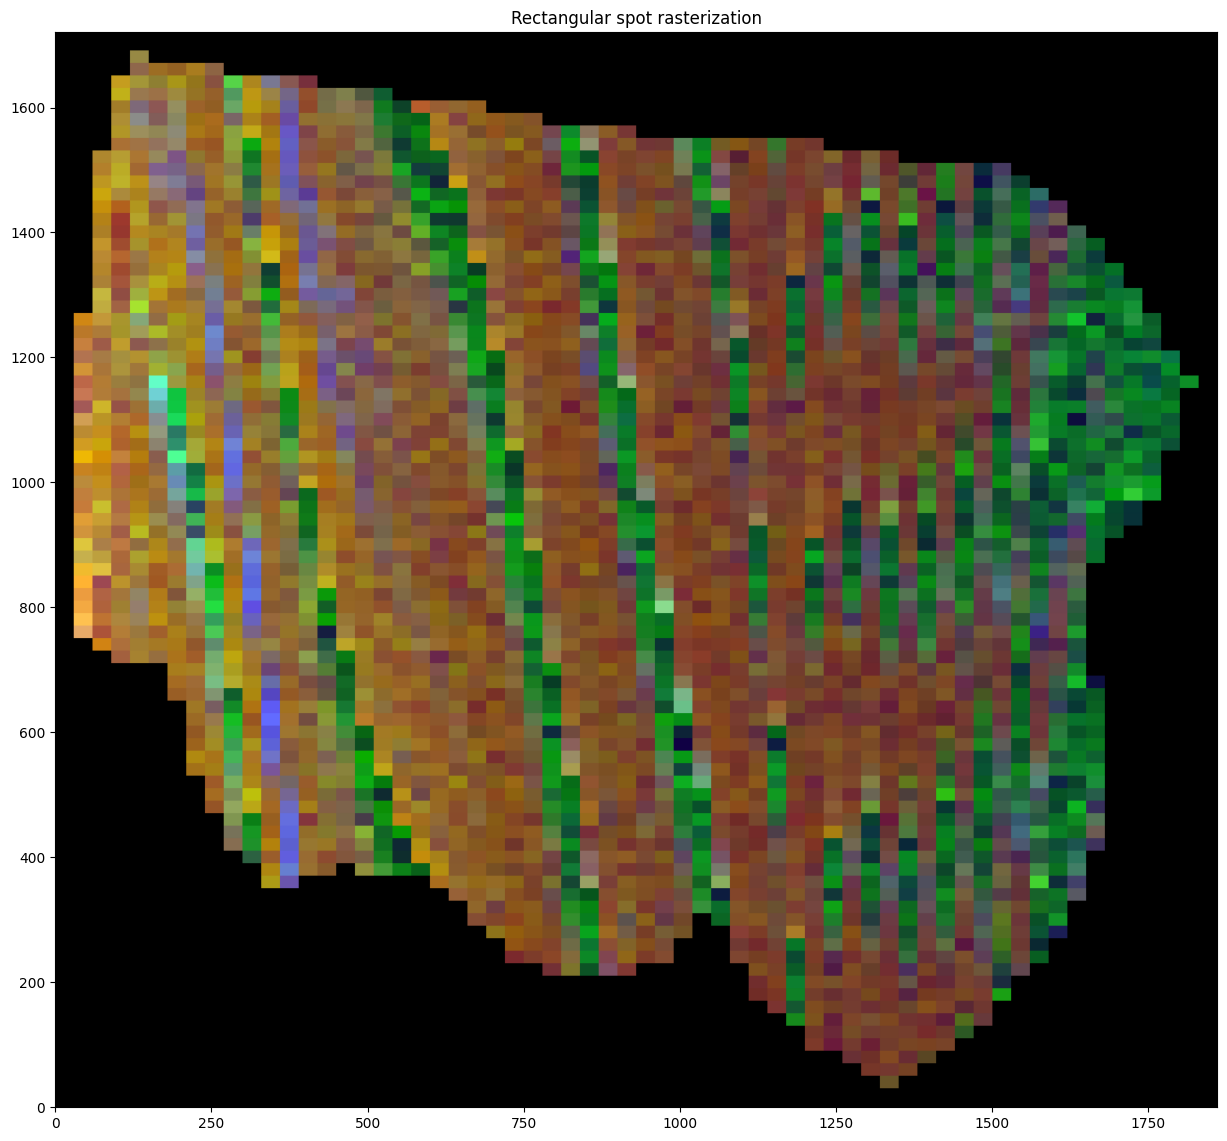

In [8]:
visualize(adata.X, adata.obsm['raster_coordinates'])

In [ ]:
lipidomics.preprocess_lipidomics(
	path=PATH,
	sample_id=SAMPLE_ID,
	modality_name=MODALITY_NAME,
	peak_picking = True,
	prominence = 0.01,
	window_tolerance = 10,
	dynamic_window = True,
	dynamic_window_factor = 1e6,
	intensity_normalization=MsiIntensityNormalization.TIC,
	force_recomputation=True
)

Reading imzML file: /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530P/MSI/pixel_test_pos_nor_15-30.imzML, associated with IBD file /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530P/MSI/pixel_test_pos_nor_15-30.ibd
Total unique M/Z values: 55088. Aligning with mass tolerance of 10 ppm and frequency threshold of 99.0 percentile.
After alignment 2973 M/Z values remain.


Aligning intensities to reference M/Z: 100%|██████████| 3573/3573 [00:00<00:00, 3809.67spectrum/s]


Applied Total Ion Current (TIC) normalization.


In [ ]:
import xml.etree.ElementTree as ET
from constants import ImzMLFileParser, MsiIntensityNormalization
def spectra_to_dict(spectra: ET.Element) -> dict:
	'''
	Convert the spectra element to a dictionary.

	Parameters
	----------
	spectra : ET.Element
		The spectra element from the imzML file.

	Returns
	-------
	dict
		A dictionary with the spectrum data.
	'''
	
	# Check input parameter type
	if not isinstance(spectra, ET.Element):
		raise TypeError('Invalid input type. Expected ET.Element.')
	
	x, y, mzs, intesities = None, None, None, None
	physical_x, physical_y = None, None

	scan_list = spectra.find(ImzMLFileParser.SCAN_LIST)
	scan = scan_list.find(ImzMLFileParser.SCAN)

	for cv_param in scan.iter(ImzMLFileParser.CV_PARAM):
		if cv_param.attrib['name'] == "position x":
			x = int(cv_param.attrib['value'])
		elif cv_param.attrib['name'] == "position y":
			y = int(cv_param.attrib['value'])
	for user_param in scan.iter(ImzMLFileParser.USER_PARAM):
		if user_param.attrib['name'] == "3DPositionX":
			physical_x = float(user_param.attrib['value'])
		if user_param.attrib['name'] == "3DPositionY":
			physical_y = float(user_param.attrib['value'])

	bdal = spectra.find(ImzMLFileParser.BINARY_DATA_ARRAY_LIST)

	for element in bdal.findall(ImzMLFileParser.BINARY_DATA_ARRAY):
		for cv_param in element.iter(ImzMLFileParser.CV_PARAM):
			if cv_param.attrib['name'] == "external array length":
				length = int(cv_param.attrib['value'])
			if cv_param.attrib['name'] == "external encoded length":
				encoded_length = int(cv_param.attrib['value'])
			if cv_param.attrib['name'] == "external offset":
				offset = int(cv_param.attrib['value'])

		if element.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_REF).attrib['ref'] in ['mzArray']:
			mzs = {
				'length': length,
				'encoded_length': encoded_length,
				'offset': offset
			}
		elif element.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_REF).attrib['ref'] in ['intensities', "intensityArray"]:
			intesities = {
				'length': length,
				'encoded_length': encoded_length,
				'offset': offset
			}

	return {'pixel_x': x, 'pixel_y': y, 'mzs': mzs, 'intensities': intesities, 'physical_x': physical_x, 'physical_y': physical_y}

# Parse the imzML file
tree = ET.parse("/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530P/MSI/pixel_test_pos_nor_15-30.imzML")
root = tree.getroot()

mz_dtype, intensities_dtype = None, None

# Define utility to convert string to dtype
str_to_dtype = lambda s: np.float32 if s == "32-bit float" else np.float64

for rpg in root.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_LIST):
	if rpg.attrib['id'] in ['mzArray']:
		for cv_param in rpg:
			if "float" in cv_param.attrib['name']:
				mz_dtype = str_to_dtype(cv_param.attrib['name'])
	elif rpg.attrib['id'] in ['intensities', "intensityArray"]:
		for cv_param in rpg:
			if "float" in cv_param.attrib['name']:
				intensities_dtype = str_to_dtype(cv_param.attrib['name'])

for scan_settings_list in root.find(ImzMLFileParser.SCAN_SETTING_LIST):
	for scan_settings in scan_settings_list:
		if scan_settings.attrib['name'] == "pixel size x":
			print(f"Pixel size x: {scan_settings.attrib['value']}")
		if scan_settings.attrib['name'] == "pixel size y":
			print(f"Pixel size y: {scan_settings.attrib['value']}")

if mz_dtype is None or intensities_dtype is None:
	raise KeyError("Could not find the data types for mz and intensities in the imzML file. Check the metadata name")

run = root.find(ImzMLFileParser.RUN_KEY)
spectrum_list = run.find(ImzMLFileParser.SPECTRUM_LIST_KEY)
spectra = spectrum_list.findall(ImzMLFileParser.SPECTRUM_KEY)

# Decode the binary data from the imzML file
parsed_spectra_pos = [spectra_to_dict(spectrum) for spectrum in spectra]

# Select the final data type based on the largest one
final_dtype = np.promote_types(mz_dtype, intensities_dtype)


# Parse the imzML file
tree = ET.parse("/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530N/MSI/pixel_test_neg_nor_15-30.imzML")
root = tree.getroot()

mz_dtype, intensities_dtype = None, None

# Define utility to convert string to dtype
str_to_dtype = lambda s: np.float32 if s == "32-bit float" else np.float64

for rpg in root.find(ImzMLFileParser.REFERENCEABLE_PARAM_GROUP_LIST):
	if rpg.attrib['id'] in ['mzArray']:
		for cv_param in rpg:
			if "float" in cv_param.attrib['name']:
				mz_dtype = str_to_dtype(cv_param.attrib['name'])
	elif rpg.attrib['id'] in ['intensities', "intensityArray"]:
		for cv_param in rpg:
			if "float" in cv_param.attrib['name']:
				intensities_dtype = str_to_dtype(cv_param.attrib['name'])

if mz_dtype is None or intensities_dtype is None:
	raise KeyError("Could not find the data types for mz and intensities in the imzML file. Check the metadata name")

run = root.find(ImzMLFileParser.RUN_KEY)
spectrum_list = run.find(ImzMLFileParser.SPECTRUM_LIST_KEY)
spectra = spectrum_list.findall(ImzMLFileParser.SPECTRUM_KEY)

# Decode the binary data from the imzML file
parsed_spectra_neg = [spectra_to_dict(spectrum) for spectrum in spectra]

# Select the final data type based on the largest one
final_dtype = np.promote_types(mz_dtype, intensities_dtype)

Pixel size x: 30
Pixel size y: 20


Estimated rotation angle (radians): 0.10136490732701756
Estimated rotation angle (radians): 0.1365954748649679
Median Y offset after affine transformation: 1.86182518291389e-07 microns


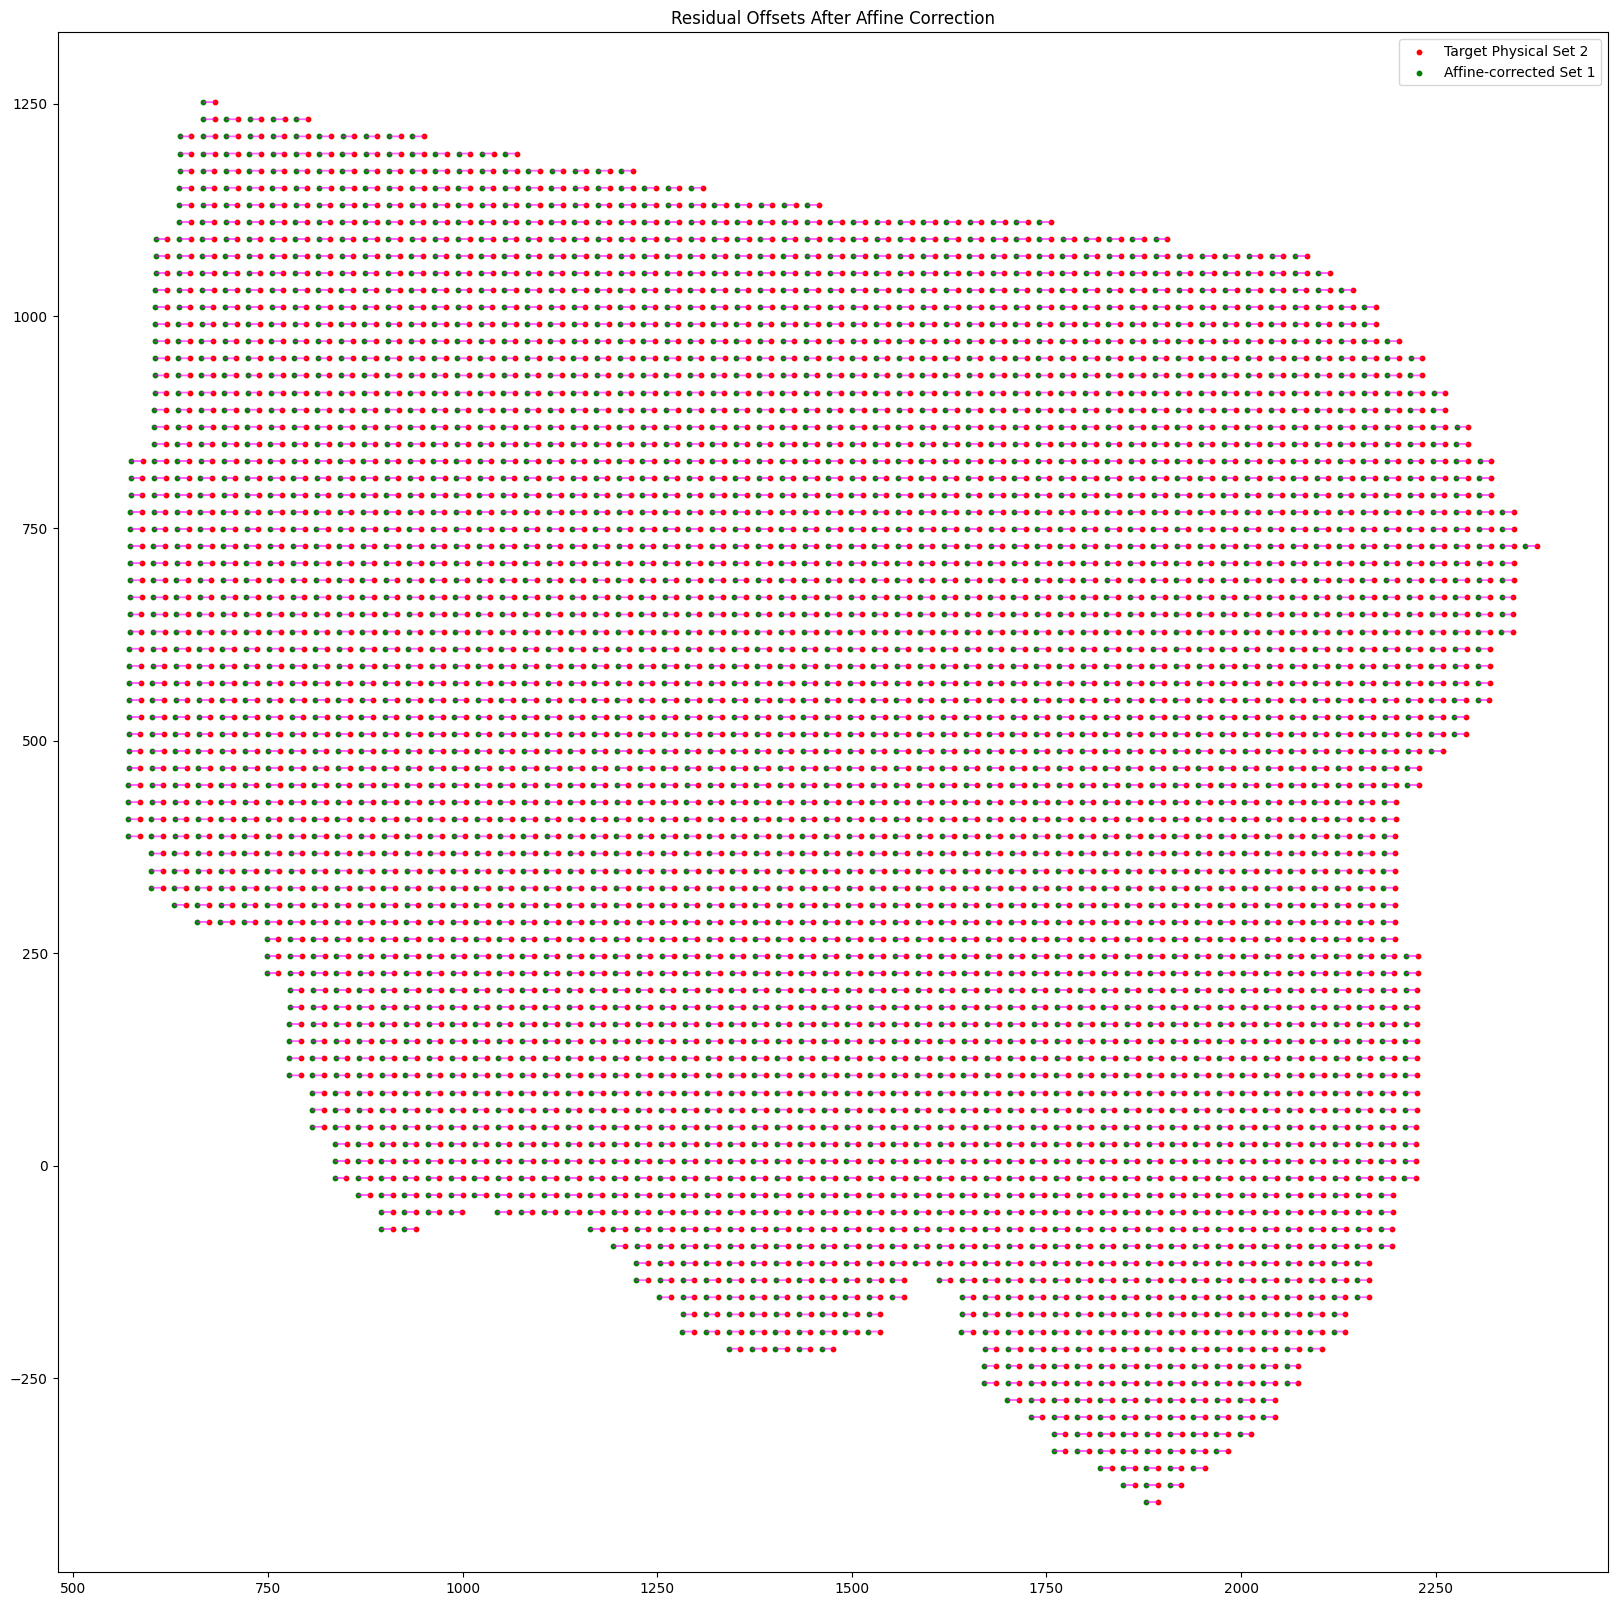

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from skimage.transform import PiecewiseAffineTransform, warp
from scipy.interpolate import Rbf

# DATASET
pixel_coords = np.array([[s['y'], s['x']] for s in parsed_spectra_pos])
phys1 = np.array([[s['physical_x'], s['physical_y']] for s in parsed_spectra_pos])
phys2 = np.array([[s['physical_x'], s['physical_y']] for s in parsed_spectra_neg])
N = len(phys1)

# Correct the rotation error in phys1 and phys2
phys1 = compute_rotation_error(phys1, pixel_coords)
phys2 = compute_rotation_error(phys2, pixel_coords)


# AFFINE TRANSFORMATION FIT
# Fit: phys2 ≈ Affine(phys1)
A = np.hstack([phys1, np.ones((N,1))])
model_x = LinearRegression().fit(A, phys2[:,0])
model_y = LinearRegression().fit(A, phys2[:,1])

def affine_transform(points):
	aug = np.hstack([points, np.ones((points.shape[0],1))])
	x_new = model_x.predict(aug)
	y_new = model_y.predict(aug)
	return np.stack([x_new, y_new], axis=1)

phys1_to_2_affine = affine_transform(phys1)

# Take into account the 15 micron offset in the y direction
phys1_to_2_affine[:,0] -= 15

# Compute the median Y offset between the transformed phys1 and phys2
y_offset = np.median(phys2[:,1] - phys1_to_2_affine[:,1])
print(f"Median Y offset after affine transformation: {y_offset} microns")
phys1_to_2_affine[:,1] += y_offset

# ASSESS CORRECTION
fig, ax = plt.subplots(figsize=(20,20))
ax.scatter(phys2[:,0], phys2[:,1], color='red', s=10, label='Target Physical Set 2')
ax.scatter(phys1_to_2_affine[:,0], phys1_to_2_affine[:,1], s = 10,color='green', label='Affine-corrected Set 1')
for i in range(N):
	ax.arrow(phys1_to_2_affine[i,0], phys1_to_2_affine[i,1],
			 phys2[i,0]-phys1_to_2_affine[i,0], phys2[i,1]-phys1_to_2_affine[i,1],
			 head_width=0.05, head_length=0.1, fc='magenta', ec='magenta', alpha=.6)
ax.set_title('Residual Offsets After Affine Correction')
ax.legend()
plt.show()



In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def compute_raster_coordinates(physical_coords: np.ndarray, raster_size: np.ndarray[np.int16]) -> np.ndarray[np.int32]:
	'''
	Convert physical coordinates (in microns) to raster pixel coordinates. This method assumes a raster pixel size of 1 micron.
	
	Parameters
	----------
	physical_coords : np.ndarray
		An (N, 2) array of physical coordinates in microns.
	raster_size : np.ndarray[np.int16]
		A (2,) array specifying the size of the raster in pixels (width, height).

	Returns
	-------
	np.ndarray[np.int32]
		An (N, 2, 2) array representing, for each physical point, the top-left and bottom-right pixel coordinates of the corresponding rectangle in the raster.
		All the raster pixels covered by the rectangle refers to the same physical point.
	'''

	# Convert center coordinates and spot size to pixel units
	min_x, min_y = physical_coords.min(axis=0)
	centers_px = np.round((physical_coords - [min_x, min_y])).astype(int)

	# Calculate output image size based on coverage (add margins for last rectangle)
	max_x, max_y = centers_px.max(axis=0)
	img_width = max_x + raster_size[0]
	img_height = max_y + raster_size[1]
	
	# Define the final output
	pixel_coords = np.zeros((physical_coords.shape[0], 2, 2), dtype=np.int32)

	for i, (cx, cy) in enumerate(centers_px):
		x1 = int(np.floor(cx - raster_size[0] / 2))
		x2 = int(np.ceil(cx + raster_size[0] / 2))
		y1 = int(np.floor(cy - raster_size[1] / 2))
		y2 = int(np.ceil(cy + raster_size[1] / 2))


		# Clamp to image boundaries
		x1 = max(0, x1)
		y1 = max(0, y1)
		x2 = min(img_width, x2)
		y2 = min(img_height, y2)
		
		





In [22]:
reference_mz = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_reference_mz.npy'))
intensities = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_intensities_matrix.npy'))

In [23]:
print(f"Reference m/z shape: {reference_mz.shape}")
print(f"Intensities shape: {intensities.shape}")

Reference m/z shape: (2973,)
Intensities shape: (61, 83, 2973)


In [24]:
alignment_engine = alignment.Aligner(PATH, SAMPLE_ID)

In [28]:
msi_image = alignment_engine._generate_msi_image(OUTPUT_PATH, decomposition_method=DecompositionMethod.NMF)

In [29]:
# Flip the image across the y-axis
#msi_image = np.flip(msi_image, axis=1)
# Flip across the x-axis
#msi_image = np.flip(msi_image, axis=0)

Text(0.5, 1.0, 'MSI Image for TEST1530P')

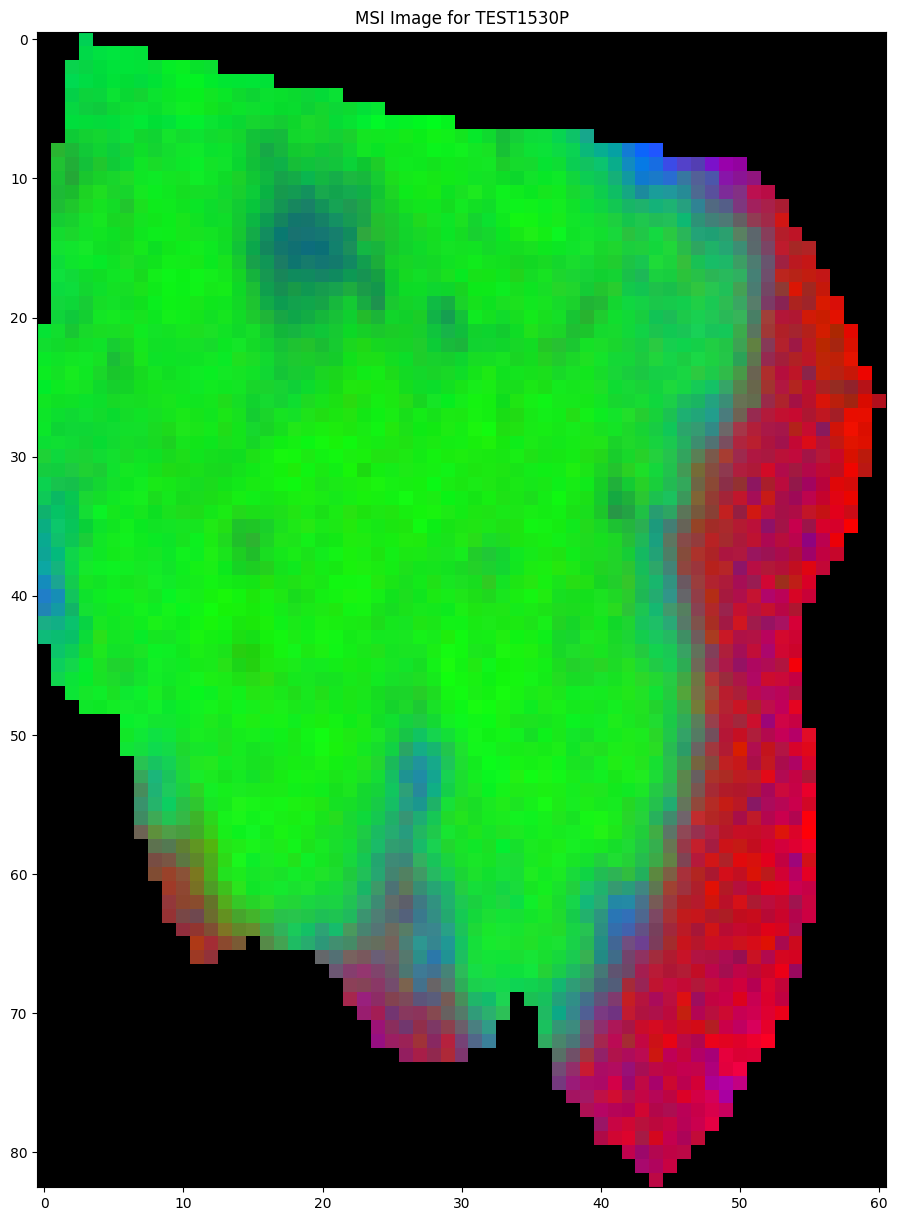

In [30]:
plt.figure(figsize=(15, 15))
plt.imshow(msi_image, cmap='gray')

plt.title(f"MSI Image for {SAMPLE_ID}")

In [65]:
prova = intensities.reshape(-1, intensities.shape[-1])
print(f"Prova shape: {prova.shape}")

filtered_intensities = prova[prova.sum(axis=1) > 0]
print(f"Filtered intensities shape: {filtered_intensities.shape}")

Prova shape: (5063, 2973)
Filtered intensities shape: (3573, 2973)


In [66]:
# Compute PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_embedding = pca.fit_transform(filtered_intensities)

# Normalize the PCA embedding
pca_embedding = (pca_embedding - np.min(pca_embedding)) / (np.max(pca_embedding) - np.min(pca_embedding))


/data/leuven/366/vsc36687/miniconda3/envs/FOCUS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0.5, 1.0, 'UMAP Embedding for TEST1530P')

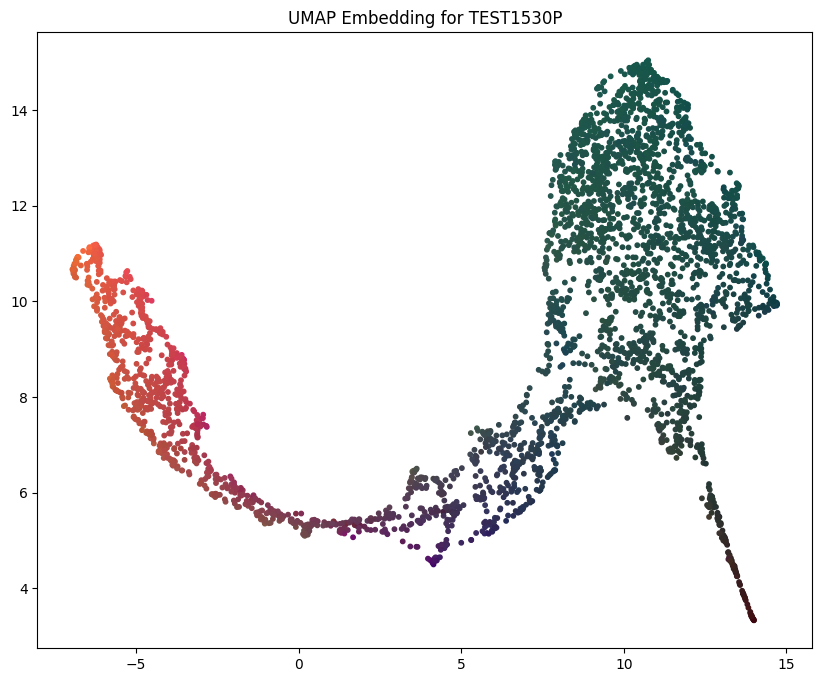

In [67]:
import umap

# Perform UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_embedding = umap_model.fit_transform(filtered_intensities)

# Plot UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=10, c=pca_embedding)
plt.title(f"UMAP Embedding for {SAMPLE_ID}")